<a href="https://colab.research.google.com/github/Chuxian-Chen/Master-Experiment/blob/main/Fair_aware_loan_approval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
!pip install tabpfn
!pip install tabpfn_client

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 7.2 MB/s eta 0:00:00
  Attempting uninstall: tqdm
    Found existing installation: tqdm 4.67.3
    Uninstalling tqdm-4.67.3:
      Successfully uninstalled tqdm-4.67.3


In [4]:
import os
import joblib
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from tabpfn import TabPFNClassifier
from scipy import stats
import warnings
import tabpfn_client
from tabpfn_client import TabPFNClassifier, TabPFNRegressor, set_access_token

# --- Import TabPFN library  ---
try:
    from google.colab import userdata
    API_TOKEN = userdata.get('API_TOKEN')
    if API_TOKEN:
        tabpfn_client.set_access_token(API_TOKEN)
        print(">>> Successfully connected with TabPFN model ")
except Exception as e:
    print(f">>> Exception: {e}")

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# >>> 2. Data preprocessing <<<
print("\n>>> 1. Loading and Preprocessing Data...")
# Ensure the path is correct relative to your current working directory
file_name = 'Loan Approval Insights Data to Decision-Making.csv'

if not os.path.exists(file_name):
    print(f"Error: File not found: {file_name}")
    print(f"Current working directory: {os.getcwd()}")
    exit()

df = pd.read_csv(file_name)

# Encoding Categorical variables
le_dict = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

try:
    # Thesis Setting: Doctorate is the privileged group S=1
    doc_id = le_dict['person_education'].transform(['Doctorate'])[0]
except:
    doc_id = 1

S = np.where(df['person_education'] == doc_id, 1, 0)
X = df.drop(columns=['loan_status'])
y = df['loan_status']

# Feature Standardization
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# >>> 3. Model dictionary <<<
models_dict = {
    "Decision Tree": DecisionTreeClassifier(min_samples_leaf=50, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "TabPFN": TabPFNClassifier()
}

# >>> 5. Core training and evaluation functions  <<<
def train_and_evaluate(model_name, model_instance, X, y, S, seed, mode='detailed'):
    X_train, X_test, y_train, y_test, S_train, S_test = train_test_split(
        X, y, S, test_size=0.2, random_state=seed, stratify=y
    )

    if model_name == "TabPFN":
        # Downsample to fit local memory constraints
        _, X_train_sub, _, y_train_sub = train_test_split(
            X_train, y_train, test_size=min(1000, len(X_train)), random_state=seed, stratify=y_train
        )
        model_instance.fit(X_train_sub, y_train_sub)
    else:
        if hasattr(model_instance, 'random_state'):
            model_instance.set_params(random_state=seed)
        model_instance.fit(X_train, y_train)

    y_prob = model_instance.predict_proba(X_test)[:, 1]
    y_pred_base = (y_prob >= 0.5).astype(int)

    acc_base = accuracy_score(y_test, y_pred_base)
    abs_spd_base = abs(y_pred_base[S_test == 1].mean() - y_pred_base[S_test == 0].mean())

    # Fairness Optimization: Threshold Shifting
    candidates = []
    thresholds = np.linspace(0.4, 0.6, 21)
    for th_doc in thresholds:
        for th_rest in thresholds:
            preds = np.array([1 if (p >= th_doc if s == 1 else p >= th_rest) else 0 for p, s in zip(y_prob, S_test)])
            curr_spd = abs(preds[S_test == 1].mean() - preds[S_test == 0].mean())
            acc = accuracy_score(y_test, preds)
            # Pareto optimal screening condition
            if curr_spd < abs_spd_base and acc > (acc_base * 0.95):
                candidates.append({'spd': curr_spd, 'acc': acc, 'preds': preds, 'th_doc': th_doc, 'th_rest': th_rest})

    if candidates:
        candidates.sort(key=lambda x: x['acc'], reverse=True)
        best = candidates[0]
        return {
            'Model': model_name,
            'Base_Acc': acc_base, 'Base_Prec': precision_score(y_test, y_pred_base, zero_division=0),
            'Base_Rec': recall_score(y_test, y_pred_base, zero_division=0),
            'Base_F1': f1_score(y_test, y_pred_base, zero_division=0),
            'Base_SPD': abs_spd_base,
            'Fair_Acc': best['acc'], 'Fair_Prec': precision_score(y_test, best['preds'], zero_division=0),
            'Fair_Rec': recall_score(y_test, best['preds'], zero_division=0),
            'Fair_F1': f1_score(y_test, best['preds'], zero_division=0),
            'Fair_SPD': best['spd'],
            'Best_Th_Doc': best['th_doc'], 'Best_Th_Rest': best['th_rest']
        } if mode == 'detailed' else (abs_spd_base, best['spd'])
    else:
        return {
            'Model': model_name,
            'Base_Acc': acc_base, 'Base_Prec': precision_score(y_test, y_pred_base, zero_division=0),
            'Base_Rec': recall_score(y_test, y_pred_base, zero_division=0),
            'Base_F1': f1_score(y_test, y_pred_base, zero_division=0),
            'Base_SPD': abs_spd_base,
            'Fair_Acc': acc_base, 'Fair_Prec': precision_score(y_test, y_pred_base, zero_division=0),
            'Fair_Rec': recall_score(y_test, y_pred_base, zero_division=0),
            'Fair_F1': f1_score(y_test, y_pred_base, zero_division=0),
            'Fair_SPD': abs_spd_base,
            'Best_Th_Doc': 0.5, 'Best_Th_Rest': 0.5
        } if mode == 'detailed' else (abs_spd_base, abs_spd_base)

# >>> 4. Paired T-test function  <<<
def calculate_paired_t_test_metrics(baseline_scores, fair_scores):
    x, y_vals = np.array(baseline_scores), np.array(fair_scores)
    n = len(x)
    d = x - y_vals
    d_bar, S_d = np.mean(d), np.std(d, ddof=1)
    se = S_d / np.sqrt(n)
    t0 = d_bar / se if se != 0 else 0
    p_val = stats.t.sf(np.abs(t0), n - 1) * 2
    return d_bar, S_d, t0, p_val

# >>> 6. Execution, Model Saving, and Table Export  <<<
if __name__ == "__main__":
    save_dir = 'Saved_Results'
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    # --- Step 2: Generate Table 4-6 ---
    print("\n>>> Generating Table 4-6 (Model Performance Comparison)...")
    detailed_results, final_thresholds = [], {}
    trained_instances = {}

    for name, clf in models_dict.items():
        print(f"    Evaluating {name}...")
        m = train_and_evaluate(name, clf, X_scaled, y, S, seed=42, mode='detailed')

        # Collect evaluation metrics
        detailed_results.append(
            {'Algorithm': name, 'Strategy': 'Baseline', 'Accuracy': m['Base_Acc'], 'Precision': m['Base_Prec'],
             'Recall': m['Base_Rec'], 'F1 Score': m['Base_F1'], 'SPD (Bias)': m['Base_SPD']})
        detailed_results.append(
            {'Algorithm': name, 'Strategy': 'Fairness-Aware', 'Accuracy': m['Fair_Acc'], 'Precision': m['Fair_Prec'],
             'Recall': m['Fair_Rec'], 'F1 Score': m['Fair_F1'], 'SPD (Bias)': m['Fair_SPD']})

        # Save thresholds and model instances for deployment
        final_thresholds[name] = (m['Best_Th_Doc'], m['Best_Th_Rest'])
        trained_instances[name] = clf

    df_4_6 = pd.DataFrame(detailed_results).round(4)
    print("\n[Table 4-6: Model Performance Comparison]")
    print(df_4_6.to_string(index=False))

    # --- Step 3: Generate Table 4-7 and 4-8  ---
    print("\n>>> Generating Table 4-7 & 4-8 (Performing 10 Iterations)...")
    raw_rows, summary_rows = [], []

    for name, clf in models_dict.items():
        print(f"    Iterating {name}...")
        b_spds, f_spds = [], []
        for i in range(10):
            b, f = train_and_evaluate(name, clf, X_scaled, y, S, seed=i, mode='spd_only')
            b_spds.append(b)
            f_spds.append(f)

        raw_rows.append([name] + b_spds)
        raw_rows.append([f"Fair-{name}"] + f_spds)

        d_bar, S_d, t_stat, p_val = calculate_paired_t_test_metrics(b_spds, f_spds)
        summary_rows.append({
            'Model': name, 'Baseline Mean SPD': np.mean(b_spds), 'Fair Model Mean SPD': np.mean(f_spds),
            'Bias Reduction': f"{((np.mean(b_spds) - np.mean(f_spds)) / np.mean(b_spds)) * 100:.1f}%",
            'd_bar': d_bar, 'S_d': S_d, 't-stat': t_stat, 'P-Value': p_val, 'Sig?': 'Yes' if p_val < 0.05 else 'No'
        })

    df_4_7 = pd.DataFrame(raw_rows, columns=['Model'] + [f'Run {i + 1}' for i in range(10)]).round(4)
    df_4_8 = pd.DataFrame(summary_rows).round(4)

    print("\n[Table 4-7: Raw SPD Values over 10 Runs]")
    print(df_4_7.to_string(index=False))

    print("\n[Table 4-8: Final Statistical Significance Summary]")
    print(df_4_8.to_string(index=False))

    # --- Step 7: Save Model Package for Flask deployment ---
    print("\n>>> [Step 7] Saving Model Package for Flask...")
    package = {
        'models': trained_instances,
        'scaler': scaler,
        'le_dict': le_dict,
        'thresholds': final_thresholds,
        'features': X.columns.tolist()
    }
    joblib.dump(package, os.path.join(save_dir, 'loan_model_package.joblib'))

    # --- Step 8: Save CSV Tables ---
    print(">>> [Step 8] Exporting Tables to CSV...")
    df_4_6.to_csv(os.path.join(save_dir, 'Table_4_6_Performance.csv'), index=False)
    df_4_7.to_csv(os.path.join(save_dir, 'Table_4_7_SPD_Runs.csv'), index=False)
    df_4_8.to_csv(os.path.join(save_dir, 'Table_4_8_Significance.csv'), index=False)

    print(f"\n>>> All tasks completed successfully. Files are saved in the folder: '{save_dir}/'")

>>> Successfully connected with TabPFN model 

>>> 1. Loading and Preprocessing Data...

>>> Generating Table 4-6 (Model Performance Comparison)...
    Evaluating Decision Tree...
    Evaluating Random Forest...
    Evaluating XGBoost...
    Evaluating TabPFN...


Processing: 100%|██████████| [00:01<00:00]



[Table 4-6: Model Performance Comparison]
    Algorithm       Strategy  Accuracy  Precision  Recall  F1 Score  SPD (Bias)
Decision Tree       Baseline    0.9190     0.8513  0.7700    0.8086      0.0245
Decision Tree Fairness-Aware    0.9194     0.8505  0.7735    0.8102      0.0143
Random Forest       Baseline    0.9288     0.8850  0.7810    0.8297      0.0070
Random Forest Fairness-Aware    0.9291     0.8750  0.7945    0.8328      0.0055
      XGBoost       Baseline    0.9220     0.8738  0.7585    0.8121      0.0220
      XGBoost Fairness-Aware    0.9229     0.8982  0.7365    0.8093      0.0203
       TabPFN       Baseline    0.9064     0.8038  0.7660    0.7844      0.0045
       TabPFN Fairness-Aware    0.9076     0.8322  0.7315    0.7786      0.0029

>>> Generating Table 4-7 & 4-8 (Performing 10 Iterations)...
    Iterating Decision Tree...
    Iterating Random Forest...
    Iterating XGBoost...
    Iterating TabPFN...


Processing: 100%|██████████| [00:01<00:00]
Processing: 100%|██████████| [00:09<00:00]
Processing: 100%|██████████| [00:01<00:00]
Processing: 100%|██████████| [00:01<00:00]
Processing: 100%|██████████| [00:01<00:00]
Processing: 100%|██████████| [00:01<00:00]
Processing: 100%|██████████| [00:01<00:00]
Processing: 100%|██████████| [00:01<00:00]
Processing: 100%|██████████| [00:01<00:00]
Processing: 100%|██████████| [00:01<00:00]



[Table 4-7: Raw SPD Values over 10 Runs]
             Model  Run 1  Run 2  Run 3  Run 4  Run 5  Run 6  Run 7  Run 8  Run 9  Run 10
     Decision Tree 0.0666 0.0033 0.0286 0.0409 0.0020 0.0001 0.0572 0.0082 0.0093  0.0006
Fair-Decision Tree 0.0465 0.0024 0.0057 0.0344 0.0010 0.0001 0.0415 0.0064 0.0092  0.0006
     Random Forest 0.0653 0.0279 0.0292 0.0483 0.0353 0.0061 0.0372 0.0156 0.0108  0.0119
Fair-Random Forest 0.0596 0.0015 0.0183 0.0041 0.0321 0.0008 0.0366 0.0071 0.0014  0.0095
           XGBoost 0.0841 0.0203 0.0415 0.0583 0.0198 0.0097 0.0495 0.0147 0.0064  0.0198
      Fair-XGBoost 0.0471 0.0062 0.0124 0.0366 0.0065 0.0001 0.0445 0.0119 0.0012  0.0130
            TabPFN 0.0431 0.0153 0.0188 0.0762 0.0076 0.0141 0.0300 0.0022 0.0257  0.0593
       Fair-TabPFN 0.0360 0.0063 0.0085 0.0527 0.0001 0.0096 0.0274 0.0016 0.0129  0.0399

[Table 4-8: Final Statistical Significance Summary]
        Model  Baseline Mean SPD  Fair Model Mean SPD Bias Reduction  d_bar    S_d  t-stat  P-V

Successfully loaded results, start process results charts
Finish Model Evaluation Results chart
Finish Distribution of data from 10 SPD experiments chart
Finish Fairness improvement and statistical significance chart

The visualization chart has been generated and saved to: 'Saved_Results/'


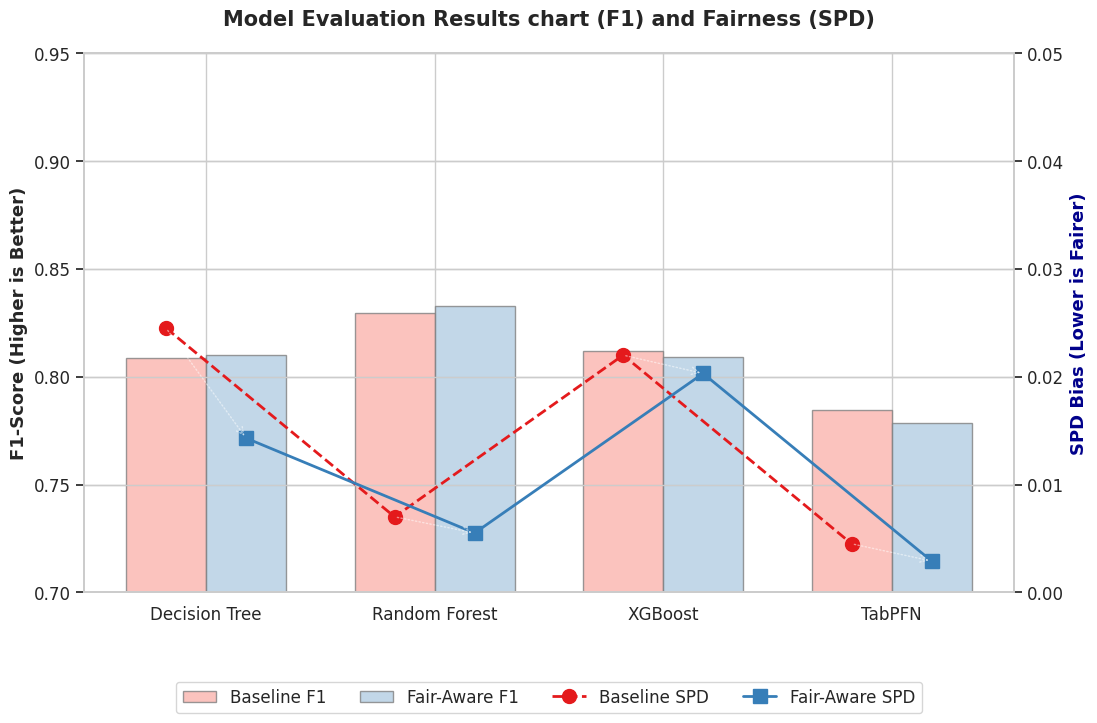

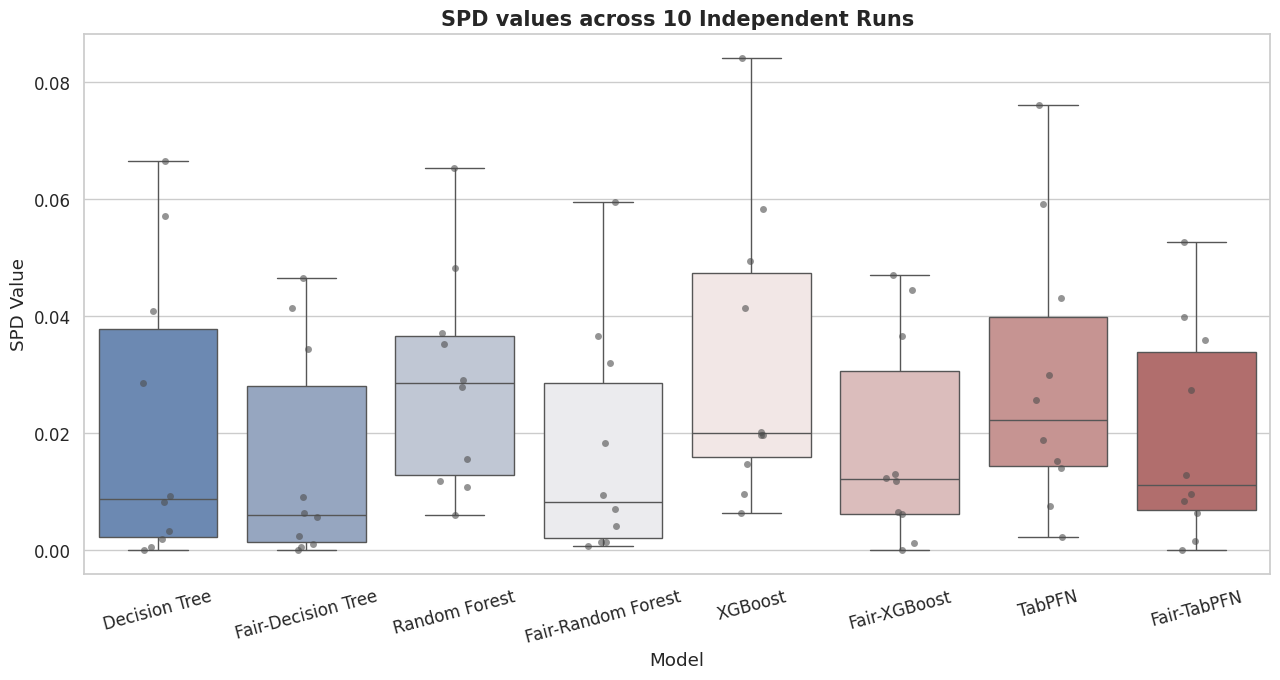

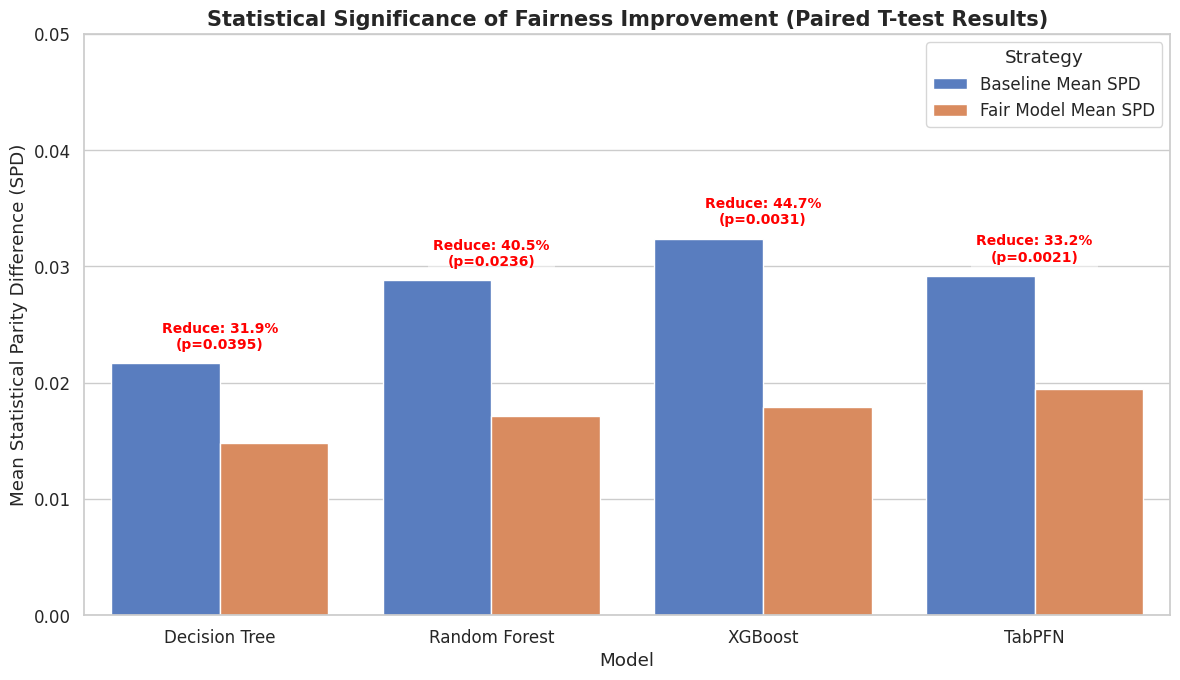

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

RESULTS_DIR = 'Saved_Results'
TABLE_4_6 = os.path.join(RESULTS_DIR, 'Table_4_6_Performance.csv')
TABLE_4_7 = os.path.join(RESULTS_DIR, 'Table_4_7_SPD_Runs.csv')
TABLE_4_8 = os.path.join(RESULTS_DIR, 'Table_4_8_Significance.csv')

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['axes.unicode_minus'] = False


def run_visualization_suite():
    for f in [TABLE_4_6, TABLE_4_7, TABLE_4_8]:
        if not os.path.exists(f):
            print(f"Error: can not find file {f}")
            return

    # Load experiment results data
    df_perf = pd.read_csv(TABLE_4_6)
    df_runs = pd.read_csv(TABLE_4_7)
    df_sig = pd.read_csv(TABLE_4_8)

    print("Successfully loaded results, start process results charts")

    # =========================================================================
    # Model Evaluation Results chart  (Based on Tables 4-6)
    # =========================================================================
    fig1, ax1_left = plt.subplots(figsize=(12, 7))
    algorithms = df_perf['Algorithm'].unique()
    x = np.arange(len(algorithms))
    width = 0.35

    # F1-Score (bar chart)
    base_f1 = df_perf[df_perf['Strategy'] == 'Baseline']['F1 Score']
    fair_f1 = df_perf[df_perf['Strategy'] == 'Fairness-Aware']['F1 Score']

    ax1_left.bar(x - width / 2, base_f1, width, label='Baseline F1', color='#fbb4ae', edgecolor='gray', alpha=0.8)
    ax1_left.bar(x + width / 2, fair_f1, width, label='Fair-Aware F1', color='#b3cde3', edgecolor='gray', alpha=0.8)

    ax1_left.set_ylabel('F1-Score (Higher is Better)', fontsize=13, fontweight='bold')
    ax1_left.set_ylim(0.70, 0.95)
    ax1_left.set_xticks(x)
    ax1_left.set_xticklabels(algorithms)

    # SPD Bias (Line chart)
    ax1_right = ax1_left.twinx()
    base_spd = df_perf[df_perf['Strategy'] == 'Baseline']['SPD (Bias)']
    fair_spd = df_perf[df_perf['Strategy'] == 'Fairness-Aware']['SPD (Bias)']

    ax1_right.plot(x - width / 2, base_spd, 'o--', color='#e41a1c', markersize=10, linewidth=2, label='Baseline SPD')
    ax1_right.plot(x + width / 2, fair_spd, 's-', color='#377eb8', markersize=10, linewidth=2, label='Fair-Aware SPD')

    # Draw descending guide line
    for i in range(len(algorithms)):
        ax1_right.annotate('', xy=(x[i] + width / 2, fair_spd.iloc[i]), xytext=(x[i] - width / 2, base_spd.iloc[i]),
                           arrowprops=dict(facecolor='black', arrowstyle='->', linestyle=':', alpha=0.5))

    ax1_right.set_ylabel('SPD Bias (Lower is Fairer)', fontsize=13, color='darkblue', fontweight='bold')
    ax1_right.set_ylim(0, 0.05)

    # Merged Legend
    h1, l1 = ax1_left.get_legend_handles_labels()
    h2, l2 = ax1_right.get_legend_handles_labels()
    ax1_left.legend(h1 + h2, l1 + l2, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=4)

    plt.title('Model Evaluation Results chart (F1) and Fairness (SPD)', fontsize=15,
              pad=20, fontweight='bold')
    plt.savefig(os.path.join(RESULTS_DIR, 'Figure_Model Evaluation Results.png'), dpi=300, bbox_inches='tight')
    print("Finish Model Evaluation Results chart")

    # =========================================================================
    # Distribution of data from 10 SPD experiments chart (based on Table 4-7)
    # =========================================================================
    plt.figure(figsize=(13, 7))
    run_cols = [c for c in df_runs.columns if 'Run' in c]
    df_runs_melted = df_runs.melt(id_vars='Model', value_vars=run_cols, var_name='Run', value_name='SPD')

    sns.boxplot(data=df_runs_melted, x='Model', y='SPD', palette='vlag', showfliers=False)
    sns.stripplot(data=df_runs_melted, x='Model', y='SPD', color=".3", size=5, jitter=True, alpha=0.6)

    plt.title('SPD values across 10 Independent Runs', fontsize=15, fontweight='bold')
    plt.ylabel('SPD Value')
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'Figur_SPD_Distribution.png'), dpi=300)
    print("Finish Distribution of data from 10 SPD experiments chart")

    # =========================================================================
    # Fairness improvement and statistical significance chart (based on Table 4-8)
    # =========================================================================
    plt.figure(figsize=(12, 7))
    # Plotting the change in average SPD
    sig_melted = df_sig.melt(id_vars=['Model', 'Bias Reduction', 'P-Value'],
                             value_vars=['Baseline Mean SPD', 'Fair Model Mean SPD'],
                             var_name='Strategy', value_name='Mean SPD')

    ax3 = sns.barplot(data=sig_melted, x='Model', y='Mean SPD', hue='Strategy', palette='muted')

    # Labeling of reduction and P-value
    for i, model in enumerate(df_sig['Model']):
        reduction = df_sig.loc[df_sig['Model'] == model, 'Bias Reduction'].values[0]
        p_val = df_sig.loc[df_sig['Model'] == model, 'P-Value'].values[0]
        y_max = df_sig.loc[df_sig['Model'] == model, 'Baseline Mean SPD'].values[0]

        # Annotation improvement rate
        ax3.text(i, y_max + 0.001, f"Reduce: {reduction}\n(p={p_val:.4f})",
                 ha='center', va='bottom', color='red', fontsize=10, fontweight='bold',
                 bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

    plt.title('Statistical Significance of Fairness Improvement (Paired T-test Results)', fontsize=15,
              fontweight='bold')
    plt.ylabel('Mean Statistical Parity Difference (SPD)')
    plt.ylim(0, 0.05)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'Figure_Significance.png'), dpi=300)
    print("Finish Fairness improvement and statistical significance chart")

    print(f"\nThe visualization chart has been generated and saved to: '{RESULTS_DIR}/'")


if __name__ == "__main__":
    run_visualization_suite()